In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import time
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import yfinance as yf

#### Data Preparation

In [2]:
import pandas as pd

df_usd = pd.read_excel('pesodollar.xlsx', header=None, skiprows=4)
df_usd = df_usd[[1, 2, 3]].copy()
df_usd.columns = ['year', 'month', 'average']
df_usd['year'] = pd.to_numeric(df_usd['year'], errors='coerce').ffill()

months = ['January','February','March','April','May','June',
          'July','August','September','October','November','December']
df_usd = df_usd[df_usd['month'].isin(months)].copy()
df_usd['month_num'] = pd.to_datetime(df_usd['month'], format='%B').dt.month
df_usd['date'] = pd.to_datetime(dict(year=df_usd['year'].astype(int), month=df_usd['month_num'], day=1))
df_usd = df_usd[['date', 'average']].rename(columns={'date': 'month', 'average': 'usd_php'})
df_usd = df_usd.set_index('month')
df_usd = df_usd[(df_usd.index >= '2021-01-01') & (df_usd['usd_php'].notna())]
df_usd

,usd_php
month,
2021-01-01,48.0614
2021-02-01,48.204167
2021-03-01,48.574304
2021-04-01,48.462
2021-05-01,47.95515
...,...
2025-12-01,58.848833
2026-01-01,59.16219
2026-02-01,58.280263


In [3]:
import pandas as pd

tickers = ['BZ=F', 'USDPHP=X']
raw = yf.download(tickers, start='2021-01-01', end='2026-06-01', interval='1d')

C:\Users\Marry Bless Magat\AppData\Local\Temp\ipykernel_34896\3968713575.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(tickers, start='2021-01-01', end='2026-06-01', interval='1d')
[*********************100%***********************]  2 of 2 completed


In [4]:
exo = raw['Close'].resample('M').first()
exo.columns = ['oil_brent', 'usd_php']
macro = exo.reset_index()
macro['month'] = macro['Date']
macro = macro.drop(['Date','usd_php'], axis =1)

In [5]:
# Load the datasets
inf = pd.read_excel('Inflation_rates_dataset_2021-2026.xlsx')
sentiment_score = pd.read_csv('finBERT Sentiment-Inflation.csv')

# Turning each month into datetime type
inf['month'] = pd.to_datetime(inf['month']).dt.to_period('M').dt.to_timestamp()
macro['month'] = pd.to_datetime(macro['month']).dt.to_period('M').dt.to_timestamp()
sentiment_score['month'] = pd.to_datetime(sentiment_score['date']).dt.to_period('M').dt.to_timestamp()

# Aligning the sentiment score monthly data format to the first two data

# Inner merge the two data
df = pd.merge(inf, macro, on= 'month', how = 'right')
# Merging the sentiment
df_final = pd.merge(sentiment_score.drop('inflation', axis =1),df , on = 'month', how = 'left').drop('date', axis = 1)
df_final = pd.merge(df_final, df_usd, left_on = 'month', right_on = df_usd.index, how = 'left')
df_final = df_final[['month', 'inflation', 'usd_php', 'oil_brent', 'sentiment']]
df_final.isna().sum()

month        0
inflation    2
usd_php      1
oil_brent    0
sentiment    0
dtype: int64

#### Visualizing the relationship of 4 Variables

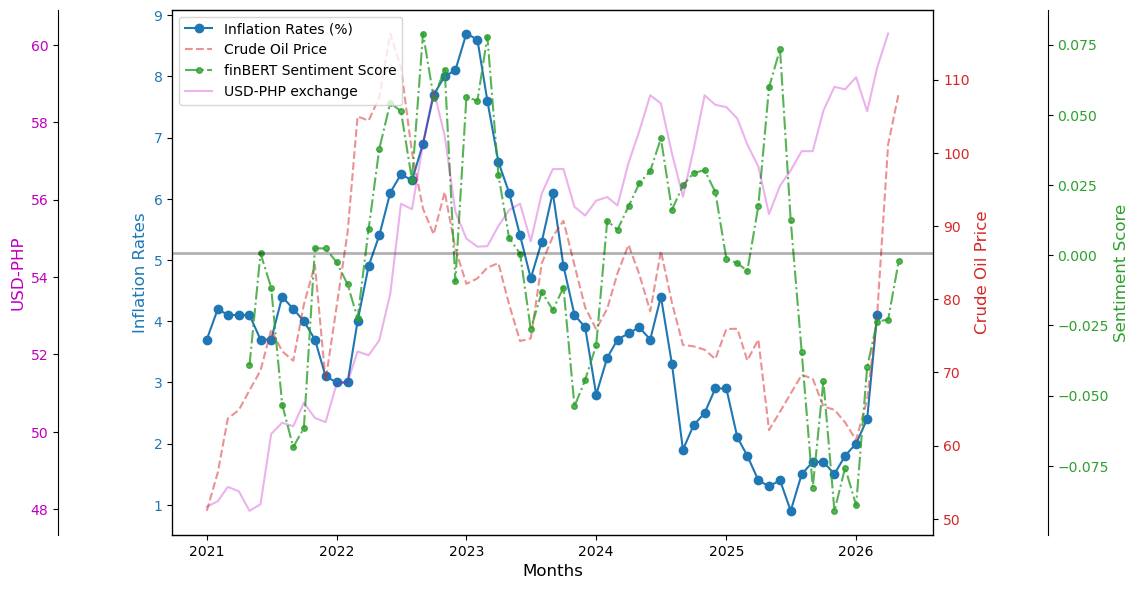

In [6]:
fig, ax1 = plt.subplots(figsize = (12,6))

ax1.plot(df_final['month'], 
         df_final['inflation'], 
         color = 'tab:blue', 
         marker = 'o', 
         label = 'Inflation Rates (%)')
ax1.set_xlabel('Months', 
               fontsize = 12)
ax1.set_ylabel('Inflation Rates', 
               color = 'tab:blue', 
               fontsize =12)
ax1.tick_params('y', 
                labelcolor ='tab:blue')

ax2 = ax1.twinx()

ax2.plot(df_final['month'], 
         df_final['oil_brent'], 
         color = 'tab:red', 
         linestyle = '--',
         alpha = 0.5,
         label = 'Crude Oil Price')
ax2.set_ylabel('Crude Oil Price', color = 'tab:red', fontsize = 12)
ax2.tick_params('y', labelcolor = 'tab:red')

ax3 = ax1.twinx()
# Moving the scale slight to right
ax3.spines['right'].set_position(('axes', 1.15))

ax3.plot(df_final['month'],
         df_final['sentiment'].rolling(window = 3).mean().shift(2), 
         color = 'tab:green', 
         linestyle = '-.',
         alpha = 0.8,
         marker = 'o',
         markersize = 4,
         label = 'finBERT Sentiment Score')
ax3.set_ylabel('Sentiment Score', 
               color = 'tab:green', 
               fontsize = 12)
ax3.tick_params('y', 
                labelcolor = 'tab:green')
ax3.axhline((df_final['sentiment'].rolling(window = 3).mean().shift(2)).mean(), 
             color = 'black', 
             linewidth = 2,
             alpha = 0.3)

ax4 = ax1.twinx()

ax4.yaxis.set_label_position('left')
ax4.yaxis.set_ticks_position('left')
ax4.spines['left'].set_position(('axes', -0.15))
ax4.plot(df_final['month'],
         df_final['usd_php'],
         color = 'm',
         alpha = 0.3,
         label = 'USD-PHP exchange')
ax4.set_ylabel('USD-PHP',
               color = 'm',
               fontsize = 12)
ax4.tick_params('y', labelcolor = 'm')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()

ax4.legend(lines+lines2+lines3+lines4,
           labels+labels2+labels3+labels4,
           loc = 'upper left')

fig.tight_layout()
plt.show()

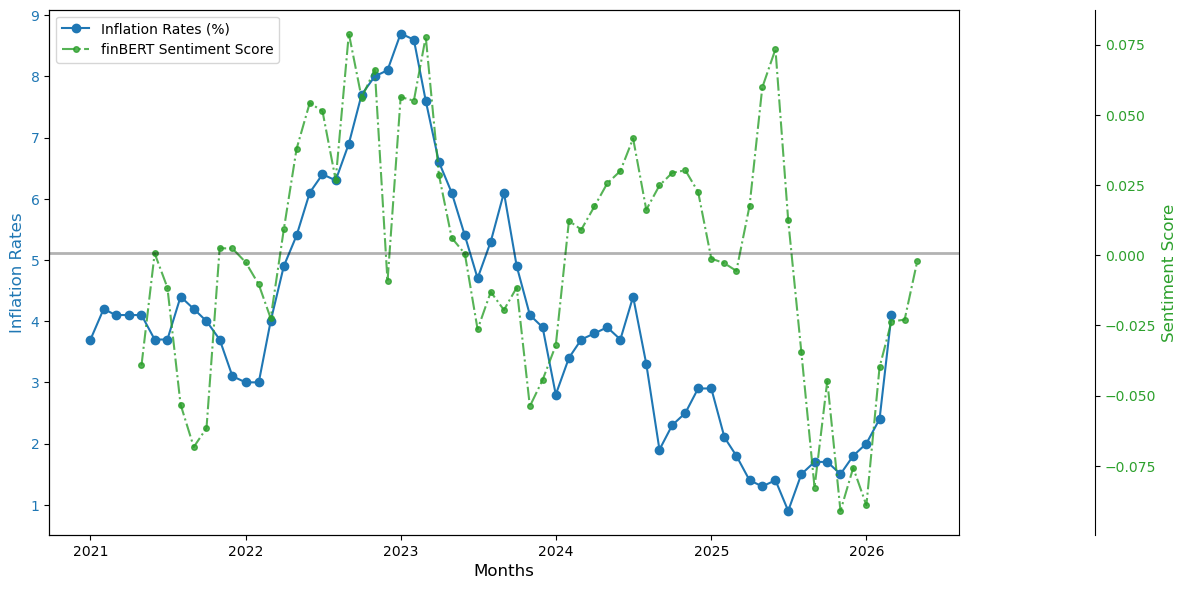

In [7]:
fig, ax1 = plt.subplots(figsize = (12,6))

ax1.plot(df_final['month'], 
         df_final['inflation'], 
         color = 'tab:blue', 
         marker = 'o', 
         label = 'Inflation Rates (%)')
ax1.set_xlabel('Months', 
               fontsize = 12)
ax1.set_ylabel('Inflation Rates', 
               color = 'tab:blue', 
               fontsize =12)
ax1.tick_params('y', 
                labelcolor ='tab:blue')


ax2 = ax1.twinx()
# Moving the scale slight to right
ax2.spines['right'].set_position(('axes', 1.15))

ax2.plot(df_final['month'],
         df_final['sentiment'].rolling(window = 3).mean().shift(2), 
         color = 'tab:green', 
         linestyle = '-.',
         alpha = 0.8,
         marker = 'o',
         markersize = 4,
         label = 'finBERT Sentiment Score')
ax2.set_ylabel('Sentiment Score', 
               color = 'tab:green', 
               fontsize = 12)
ax2.tick_params('y', 
                labelcolor = 'tab:green')
ax2.axhline((df_final['sentiment'].rolling(window = 3).mean().shift(2)).mean(), 
             color = 'black', 
             linewidth = 2,
             alpha = 0.3)


lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()


ax2.legend(lines+lines2,
           labels+labels2,
           loc = 'upper left')

fig.tight_layout()
plt.show()

#### Check correlation of data

In [8]:
inf_sent_corr = df_final['inflation'].corr(df_final['sentiment'].rolling(window = 3).mean().shift(-2))
inf_oil_Corr = df_final['inflation'].corr(df_final['oil_brent'])
inf_USD_Php_Corr = df_final['inflation'].corr(df_final['usd_php'].pct_change())
print(f'Inflation - Sentiment Corr: {inf_sent_corr}')
print(f'Inflatoin - Oil Corr: {inf_oil_Corr}')
print(f'Inflation - USD/PhP Corr: {inf_USD_Php_Corr}')

for lag in [1, 2, 3, 4, 5, 6, 7]:
    lagged_corr = df_final['inflation'].corr(df_final['usd_php'].pct_change().shift(lag))
    print(f"USD/PHP % Change (Lag {lag}) vs Inflation Corr: {lagged_corr:.4f}")

Inflation - Sentiment Corr: 0.34750761144258835
Inflatoin - Oil Corr: 0.5816142127598297
Inflation - USD/PhP Corr: 0.02152288658972815
USD/PHP % Change (Lag 1) vs Inflation Corr: 0.0723
USD/PHP % Change (Lag 2) vs Inflation Corr: 0.1007
USD/PHP % Change (Lag 3) vs Inflation Corr: 0.1307
USD/PHP % Change (Lag 4) vs Inflation Corr: 0.1616
USD/PHP % Change (Lag 5) vs Inflation Corr: 0.1750
USD/PHP % Change (Lag 6) vs Inflation Corr: 0.2296
USD/PHP % Change (Lag 7) vs Inflation Corr: 0.2499


C:\Users\Marry Bless Magat\AppData\Local\Temp\ipykernel_34896\563119383.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  inf_USD_Php_Corr = df_final['inflation'].corr(df_final['usd_php'].pct_change())
C:\Users\Marry Bless Magat\AppData\Local\Temp\ipykernel_34896\563119383.py:9: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  lagged_corr = df_final['inflation'].corr(df_final['usd_php'].pct_change().shift(lag))


In [9]:
for lag in [1, 2, 3, 4]:
    lagged_corr = df_final['inflation'].corr(df_final['sentiment'].rolling(window = 3).mean().shift(lag))
    print(f"Sentiment (Lag {lag}) vs Inflation Corr: {lagged_corr:.4f}")

Sentiment (Lag 1) vs Inflation Corr: 0.4294
Sentiment (Lag 2) vs Inflation Corr: 0.4417
Sentiment (Lag 3) vs Inflation Corr: 0.4162
Sentiment (Lag 4) vs Inflation Corr: 0.3793


In [10]:
agged_corr = df_final['inflation'].corr(df_final['oil_brent'])
print(agged_corr)
for lag in [1, 2, 3, 4]:
    lagged_corr = df_final['inflation'].corr(df_final['oil_brent'].rolling(window = 3).mean().shift(lag))
    print(f"Oil Brent (Lag {lag}) vs Inflation Corr: {lagged_corr:.4f}")

0.5816142127598297
Oil Brent (Lag 1) vs Inflation Corr: 0.6652
Oil Brent (Lag 2) vs Inflation Corr: 0.6859
Oil Brent (Lag 3) vs Inflation Corr: 0.7120
Oil Brent (Lag 4) vs Inflation Corr: 0.7293


#### Building ARIMA/SARIMA model

In [11]:
# Separating Inflation dataset

# Splitting the data to train-test sets 
train_size = int(len(df_final)*.8)
inf_train = df_final[0:train_size]
inf_test = df_final[train_size:int(len(df_final))]

# Check the data 
print(f'Trainig on: {inf_train.index.min()} to {inf_train.index.max()}')
print(f'Testing on: {inf_test.index.min()} to {inf_test.index.max()}')

Trainig on: 0 to 51
Testing on: 52 to 64


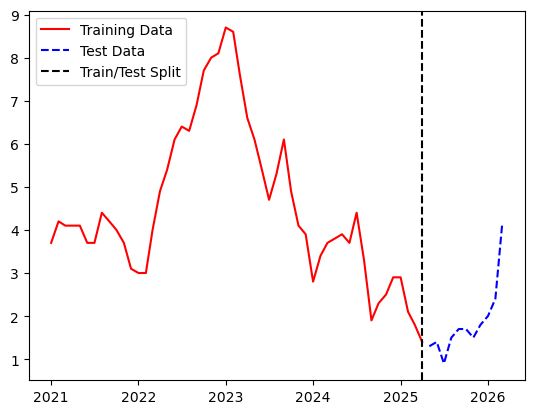

In [12]:
fig = plt.plot(figsize = (30,15))

plt.plot(inf_train['month'], inf_train['inflation'], color  = 'red', label = 'Training Data')
plt.plot(inf_test['month'], inf_test['inflation'], color = 'blue', linestyle = '--', label = 'Test Data')

plt.axvline(inf_train['month'].max(), color = 'black', linestyle = '--', label = 'Train/Test Split')

plt.legend()
plt.show()

### Checking Assumptions for building ARIMA/SARIMA model

##### Stationarity Check

In [13]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series):
    result = adfuller(series)[1]

    if result > 0.05:
        print(f'ADF: {result}, differencing is needed')
    else:
        print(f'ADF: {result}, no differencing needed. Data is stationary')

adf_test(inf_train['inflation'].dropna())

ADF: 0.3546636275136579, differencing is needed


##### Seasonality Check

In [14]:
from pmdarima.arima.utils import nsdiffs

def n_diffs(series):
    result = nsdiffs(series, m = 12, test = 'ocsb')
    print(f'Suggested Seasonal Differencing: {result}')

n_diffs(inf_train['inflation'].dropna())

Suggested Seasonal Differencing: 0


C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


##### Seasonal and Trend Decomposition

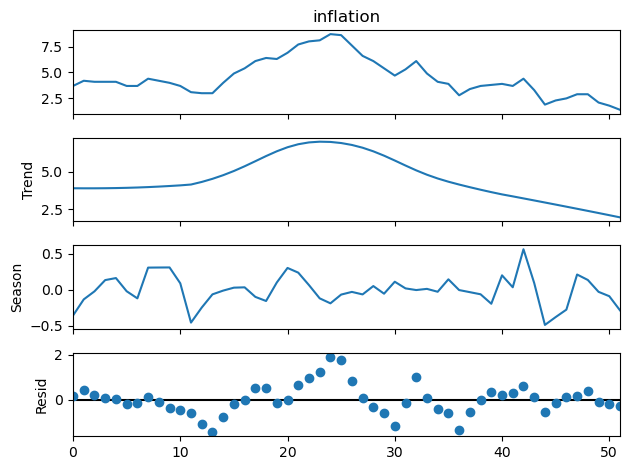

In [15]:
from statsmodels.tsa.seasonal import STL

res = STL(inf_train['inflation'].dropna(), period = 12).fit()
res.plot()
plt.show()

##### ACF/PCF plotting to further check seasonality

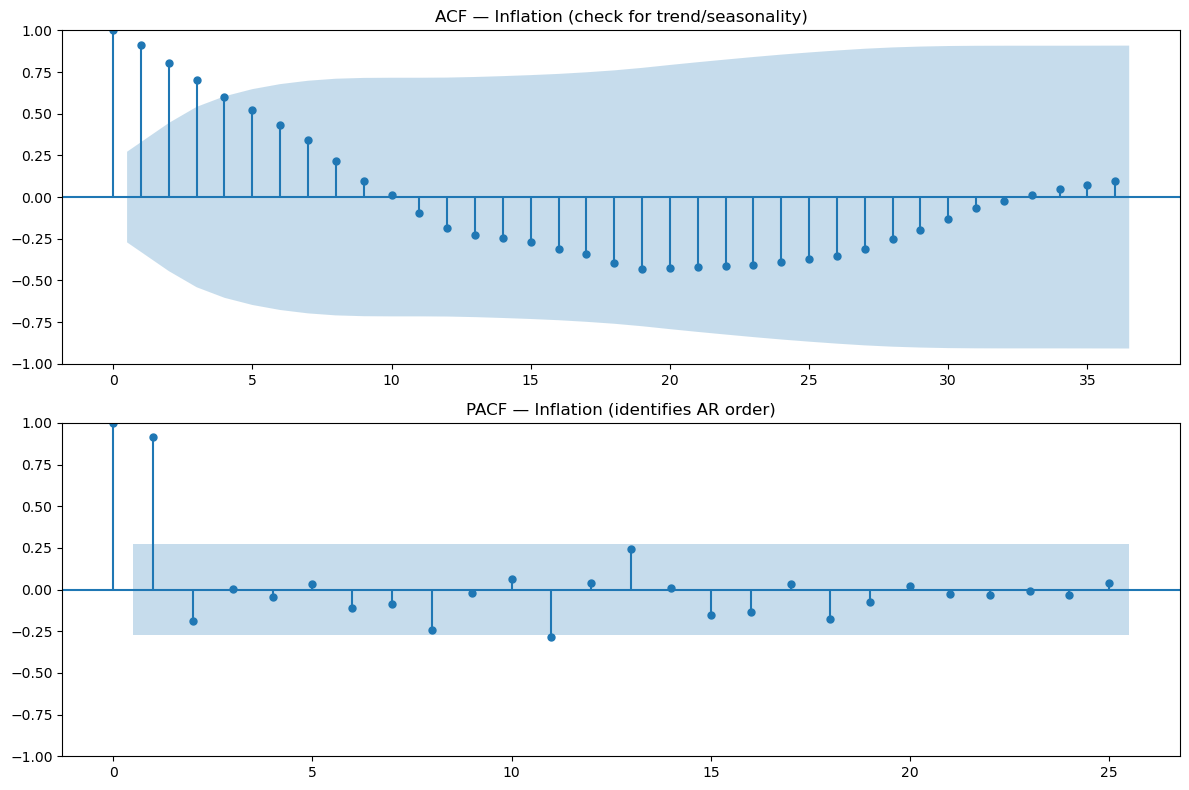

In [16]:
import statsmodels.api as sm

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# ACF
sm.graphics.tsa.plot_acf(
    inf_train['inflation'].dropna(),
    lags=36,
    alpha=0.05,
    ax=axes[0],
    title='ACF — Inflation (check for trend/seasonality)'
)

# PACF — run this alongside ACF always
sm.graphics.tsa.plot_pacf(
    inf_train['inflation'].dropna(),
    lags=25,
    alpha=0.05,
    method='ywm',
    ax=axes[1],
    title='PACF — Inflation (identifies AR order)'
)

plt.tight_layout()
plt.show()




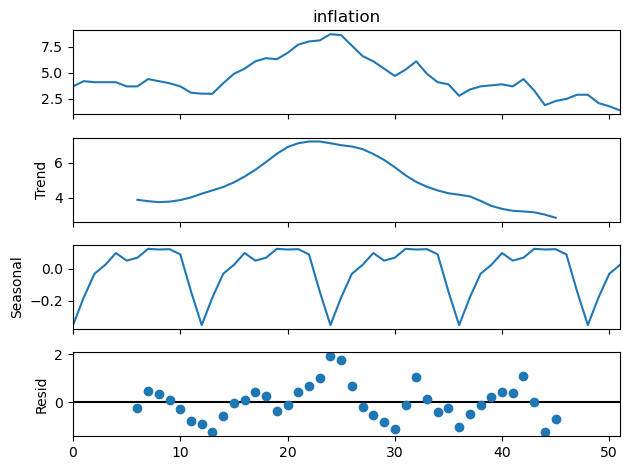

In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(inf_train['inflation'].dropna(),
                            model = 'additive',
                            period = 12)

decomp.plot()
plt.tight_layout()
plt.show()

# This shows that nsdiffs prove that no Seasonal Differencing needed
# While other tests like ACF and PACF and Seasonal Decomposition shows that there is a weak seasonality.
# Auto ARIMA will be used and make sure that Seasonal Differencing is not included

In [18]:
from pmdarima import auto_arima
arima_model = auto_arima(
    inf_train['inflation'].dropna(),
    seasonal=True,
    m=12,
    d=1,          # force differencing since ADF confirmed it
    D=0,          # no seasonal differencing per nsdiffs
    max_p=3,
    max_q=3,
    max_P=2,
    max_Q=2,
    stepwise=False,   # exhaustive search instead of stepwise
    information_criterion='aic',
    trace=True
)
orders = arima_model.order

C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=96.867, Time=0.07 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=inf, Time=0.13 sec
 ARIMA(0,1,0)(0,0,2)[12] intercept   : AIC=inf, Time=0.37 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=81.238, Time=0.08 sec


C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.22 sec


C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(3,1,1)(0,0,0)[12] intercept   : AIC=88.155, Time=0.11 sec


C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(3,1,1)(0,0,1)[12] intercept   : AIC=inf, Time=0.30 sec
 ARIMA(3,1,1)(1,0,0)[12] intercept   : AIC=74.438, Time=0.17 sec


C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(3,1,2)(0,0,0)[12] intercept   : AIC=89.470, Time=0.22 sec

Best model:  ARIMA(1,1,1)(1,0,0)[12] intercept
Total fit time: 20.301 seconds


In [19]:
train_residuals = arima_model.resid()
arima_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                   52
Model:             SARIMAX(1, 1, 1)x(1, 0, [], 12)   Log Likelihood                 -31.844
Date:                             Fri, 29 May 2026   AIC                             73.688
Time:                                     21:21:08   BIC                             83.347
Sample:                                          0   HQIC                            77.379
                                              - 52                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0642      0.153     -0.421      0.674      -0.363       0.235
ar.L1         -0.4890      0.194     -2.514      0.012      -0.870      -0.108
ma.L1          0.9682      0.124      7.781      0.000       0.724       1.212
ar.S.L12      -0.5216      0.143     -3.659      0.000      -0.801      -0.242
sigma2         0.1810      0.041      4.416      0.000       0.101       0.261
===================================================================================
Ljung-Box (L1) (Q):                   0.11   Jarque-Bera (JB):                 0.05
Prob(Q):                              0.74   Prob(JB):                         0.97
Heteroskedasticity (H):               1.20   Skew:                            -0.03
Prob(H) (two-sided):                  0.72   Kurtosis:                         2.85
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [20]:
inf_train = inf_train.set_index('month')

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                   52
Model:             SARIMAX(1, 1, 1)x(1, 0, [], 12)   Log Likelihood                 -31.844
Date:                             Fri, 29 May 2026   AIC                             73.688
Time:                                     21:21:08   BIC                             83.347
Sample:                                          0   HQIC                            77.379
                                              - 52                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0642      0.153     -0.421      0.674      -0.363       0.235
ar.L1         -0.4890      

C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Marry Bless Magat\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


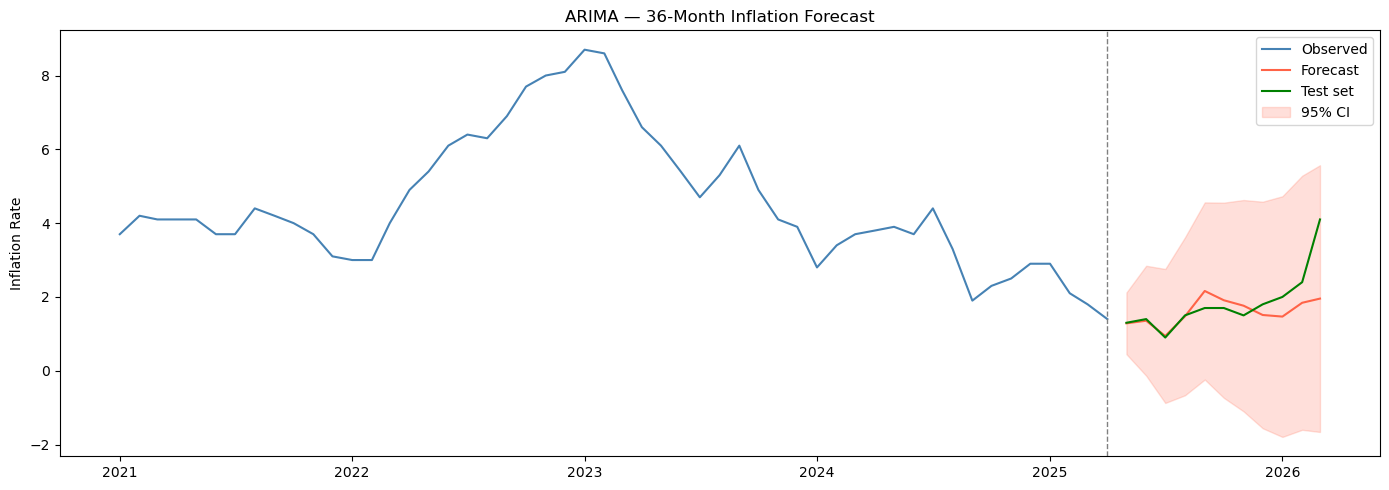

            forecast  lower_ci  upper_ci
2025-05-01  1.284555  0.449224  2.119886
2025-06-01  1.355605 -0.133528  2.844738
2025-07-01  0.942543 -0.872909  2.757995
2025-08-01  1.475526 -0.664714  3.615766
2025-09-01  2.161477 -0.238980  4.561934
2025-10-01  1.910277 -0.734280  4.554834
2025-11-01  1.762556 -1.101118  4.626231
2025-12-01  1.510927 -1.558201  4.580056
2026-01-01  1.467735 -1.793033  4.728503
2026-02-01  1.841915 -1.600255  5.284085
2026-03-01  1.955251 -1.659034  5.569535


In [21]:
from pmdarima import auto_arima
import matplotlib.pyplot as plt
import pandas as pd


print(arima_model.summary())



# --- Step 2: Forecast 36 months ---
n_forecast = 11
forecast, conf_int = arima_model.predict(n_periods=n_forecast, return_conf_int=True)

last_date = inf_train['inflation'].dropna().index[-1]
forecast_index = pd.date_range(start=last_date, periods=n_forecast + 1, freq='MS')[1:]

forecast_df = pd.DataFrame({
    'forecast':   forecast.values,
    'lower_ci':   conf_int[:, 0],
    'upper_ci':   conf_int[:, 1]
}, index=forecast_index)

# --- Step 3: Plot ---
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(inf_train['inflation'], label='Observed', color='steelblue')
ax.plot(forecast_df['forecast'], label='Forecast', color='tomato')
ax.plot(forecast_df.index, inf_test['inflation'].dropna(), label = 'Test set', color = 'green')
ax.fill_between(forecast_df.index,
                forecast_df['lower_ci'],
                forecast_df['upper_ci'],
                alpha=0.2, color='tomato', label='95% CI')

ax.axvline(x=last_date, color='gray', linestyle='--', linewidth=1)
ax.set_title('ARIMA — 36-Month Inflation Forecast')
ax.set_ylabel('Inflation Rate')
ax.legend()
plt.tight_layout()
plt.savefig('prelimenary_plot.png', dpi = 150, bbox_inches = 'tight')
plt.show()

print(forecast_df)

In [22]:
len(inf_test['inflation'].dropna())

11

In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error

def err_metrics(y_true, y_pred):
    # 1. Mean Squared Error (MSE)
    mse = mean_squared_error(y_true, y_pred)
    
    # 2. Root Mean Squared Error (RMSE)
    # In newer versions of sklearn, you can use squared=False
    rmse = root_mean_squared_error(y_true, y_pred)
    
    # 3. Mean Absolute Error (MAE)
    mae = mean_absolute_error(y_true, y_pred)

    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}")
    print(f"MAE: {mae}")

err_metrics(inf_test['inflation'].dropna(), forecast.values)

MSE: 0.5099099232079017
RMSE: 0.714079773700321
MAE: 0.41684898144454774


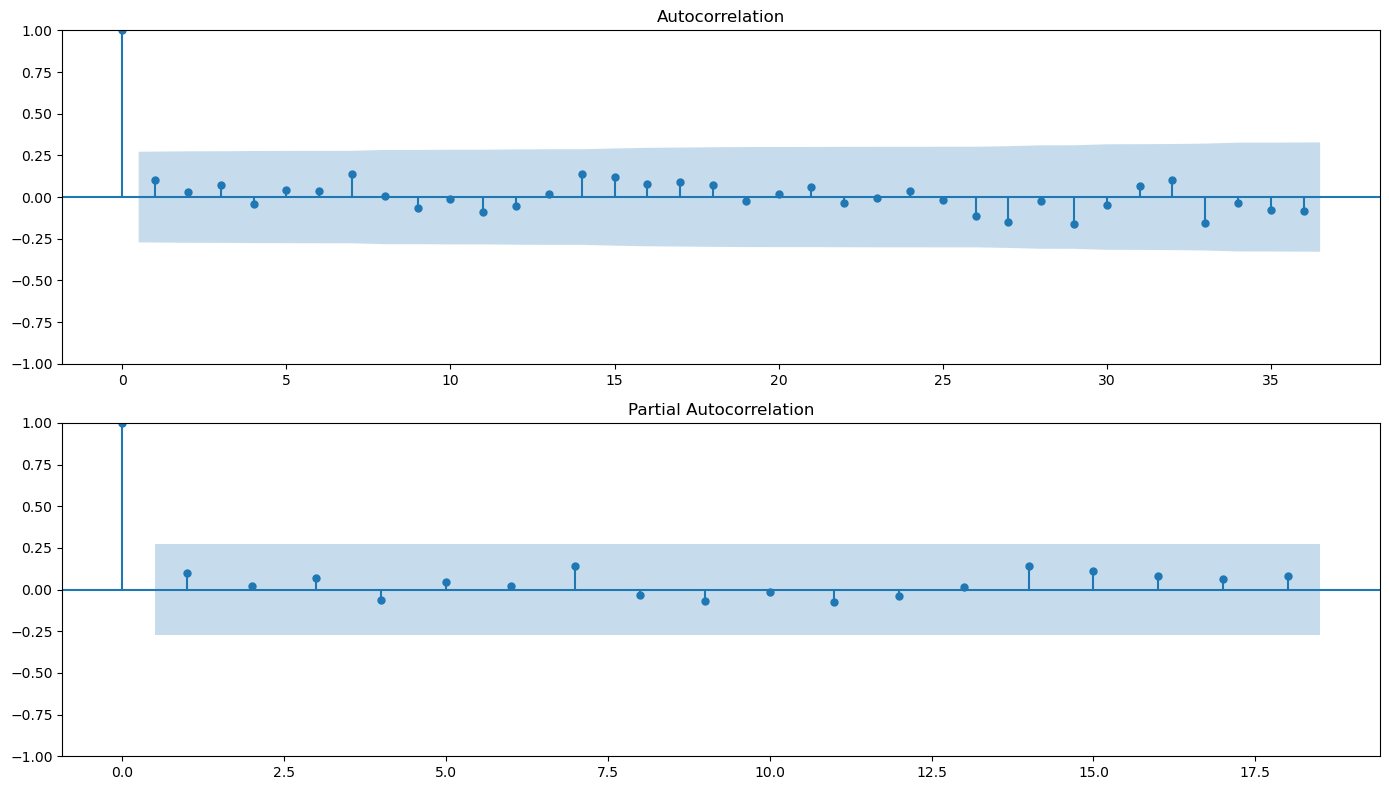

In [24]:
stand_resid = arima_model.resid()

fig, ax = plt.subplots(2,1, figsize = (14,8))

plot_acf(stand_resid, ax = ax[0], lags = 36)
plot_pacf(stand_resid, ax = ax[1], lags = 18)

plt.tight_layout()
plt.show()

In [25]:
sig_lags = [14,15]

In [26]:
train_feature = inf_train.drop(['inflation'], axis = 1).copy()

train_feature

,usd_php,oil_brent,sentiment
month,,,
2021-01-01,48.0614,51.090000,-0.096034
2021-02-01,48.204167,56.349998,0.019575
2021-03-01,48.574304,63.689999,-0.041243
2021-04-01,48.462,64.860001,0.023667
2021-05-01,47.95515,67.559998,-0.017046
2021-06-01,48.124727,70.250000,-0.166092
2021-07-01,49.942952,75.839996,-0.021759
2021-08-01,50.234333,72.889999,0.003194
2021-09-01,50.142136,71.589996,0.026007


In [27]:
train_feature['usd_php'] = train_feature['usd_php'].pct_change().shift(4)
train_feature['oil_brent'] = train_feature['oil_brent'].rolling(window = 3).mean().shift(2)
train_feature['sentiment'] = train_feature['sentiment'].rolling(window = 3).mean().shift(2)

train_feature = train_feature.dropna()

In [28]:
train_feature

,usd_php,oil_brent,sentiment
month,,,
2021-06-01,0.002971,61.633333,0.000666
2021-07-01,0.007679,65.369999,-0.011541
2021-08-01,-0.002312,67.556666,-0.053157
2021-09-01,-0.010459,71.216665,-0.068299
2021-10-01,0.003536,72.993332,-0.061552
2021-11-01,0.037782,73.439997,0.002481
2021-12-01,0.005834,74.586665,0.002395
2022-01-01,-0.001835,78.526665,-0.002489
2022-02-01,0.012106,77.620000,-0.010425


In [29]:
resid_df = pd.DataFrame(stand_resid, columns = ['target_residuals'])

resid_df = resid_df.iloc[5:].set_index(train_feature.index)

In [30]:
train_feature.loc[:, 'target_residuals'] = resid_df['target_residuals']
train_feature

C:\Users\Marry Bless Magat\AppData\Local\Temp\ipykernel_34896\291003642.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_feature.loc[:, 'target_residuals'] = resid_df['target_residuals']


,usd_php,oil_brent,sentiment,target_residuals
month,,,,
2021-06-01,0.002971,61.633333,0.000666,-0.283462
2021-07-01,0.007679,65.369999,-0.011541,0.094319
2021-08-01,-0.002312,67.556666,-0.053157,0.656991
2021-09-01,-0.010459,71.216665,-0.068299,-0.396841
2021-10-01,0.003536,72.993332,-0.061552,0.088920
2021-11-01,0.037782,73.439997,0.002481,-0.410217
2021-12-01,0.005834,74.586665,0.002395,-0.389586
2022-01-01,-0.001835,78.526665,-0.002489,0.116444
2022-02-01,0.012106,77.620000,-0.010425,0.253200


In [31]:
print(train_feature.head())
print(train_feature.shape)
print(train_feature.isnull().sum())

             usd_php  oil_brent  sentiment  target_residuals
month                                                       
2021-06-01  0.002971  61.633333   0.000666         -0.283462
2021-07-01  0.007679  65.369999  -0.011541          0.094319
2021-08-01 -0.002312  67.556666  -0.053157          0.656991
2021-09-01 -0.010459  71.216665  -0.068299         -0.396841
2021-10-01  0.003536  72.993332  -0.061552          0.088920
(47, 4)
usd_php             0
oil_brent           0
sentiment           0
target_residuals    0
dtype: int64


In [32]:
X = train_feature.drop('target_residuals', axis = 1)
y = train_feature['target_residuals']

In [33]:
rf_model = RandomForestRegressor(
    n_estimators = 500,
    max_depth=10,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X,y)

RandomForestRegressor(max_depth=10, min_samples_leaf=2, n_estimators=500,
                      random_state=42)

In [34]:
test_feature = inf_test.drop(['inflation'], axis = 1).copy()
test_feature['usd_php'] = test_feature['usd_php'].pct_change().shift(4)
test_feature['oil_brent'] = test_feature['oil_brent'].rolling(window = 3).mean().shift(2)
test_feature['sentiment'] = test_feature['sentiment'].rolling(window = 3).mean().shift(2)

test_feature = test_feature.dropna().set_index('month')
test_feature.shape
test_feature

C:\Users\Marry Bless Magat\AppData\Local\Temp\ipykernel_34896\3127664691.py:2: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  test_feature['usd_php'] = test_feature['usd_php'].pct_change().shift(4)


,usd_php,oil_brent,sentiment
month,,,
2025-10-01,0.013195,67.136665,-0.044710
2025-11-01,0.006987,68.639999,-0.091018
2025-12-01,0.008813,68.053332,-0.075687
2026-01-01,-0.000043,66.459999,-0.089042
2026-02-01,0.018311,64.469999,-0.039849
2026-03-01,0.010552,62.936666,-0.023607
2026-04-01,-0.001099,63.406667,-0.022942
2026-05-01,0.005325,68.263334,-0.001923


In [35]:
boundary_df = pd.concat([inf_train.tail(4).drop(['inflation'],axis = 1), inf_test.drop(['inflation'],axis = 1)])

boundary_df['usd_php'] = boundary_df['usd_php'].pct_change().shift(4)
boundary_df['oil_brent'] = boundary_df['oil_brent'].rolling(window = 3).mean().shift(2)
boundary_df['sentiment'] = boundary_df['sentiment'].rolling(window = 3).mean().shift(2)

test_feature = boundary_df.iloc[6:].set_index('month')

print(f'Train length: {len(train_feature)}')
test_feature

Train length: 47


C:\Users\Marry Bless Magat\AppData\Local\Temp\ipykernel_34896\1715299791.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  boundary_df['usd_php'] = boundary_df['usd_php'].pct_change().shift(4)


,usd_php,oil_brent,sentiment
month,,,
2025-07-01,-0.011526,69.413334,0.012431
2025-08-01,-0.009955,67.083332,-0.034575
2025-09-01,-0.021605,64.623333,-0.082713
2025-10-01,0.013195,67.136665,-0.044710
2025-11-01,0.006987,68.639999,-0.091018
2025-12-01,0.008813,68.053332,-0.075687
2026-01-01,-0.000043,66.459999,-0.089042
2026-02-01,0.018311,64.469999,-0.039849
2026-03-01,0.010552,62.936666,-0.023607


In [36]:
rf_residual_pred = rf_model.predict(test_feature)

In [37]:
corrected_rf_forecast = forecast.values[:len(rf_residual_pred)]+rf_residual_pred
corrected_rf_forecast

array([1.12929338, 1.45834999, 0.95521142, 1.60602746, 2.33152952,
       2.10677772, 1.97502211, 1.58922616, 1.83353081, 2.31759093,
       1.69290637])

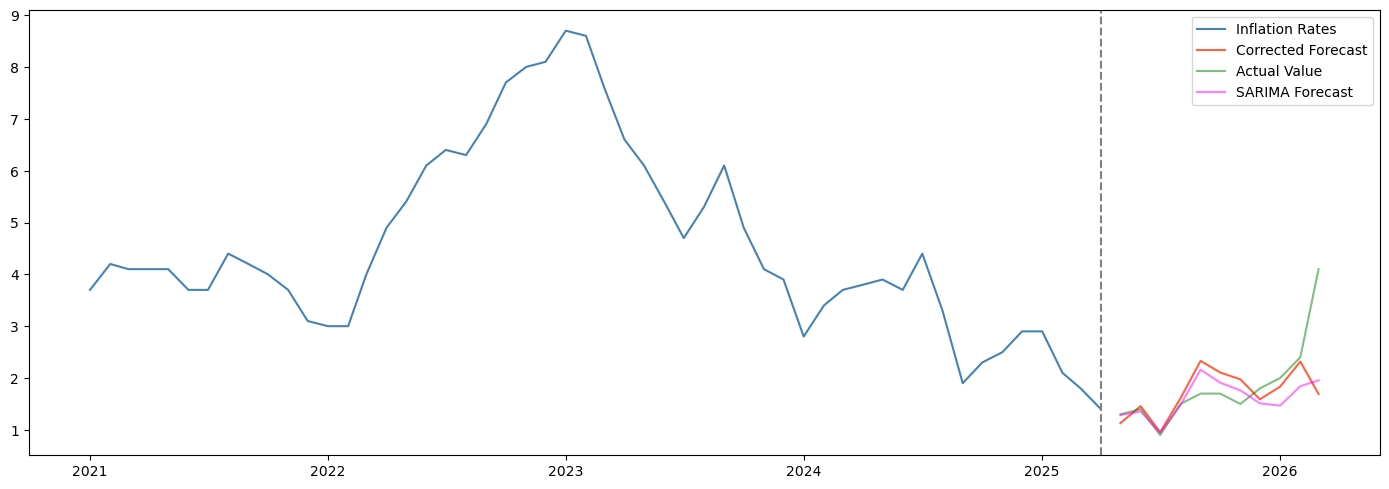

In [38]:
last_date = inf_train.index[-1]
index_range = pd.date_range(start = last_date, periods = len(corrected_rf_forecast)+1, freq='MS')[1:]

fig, ax = plt.subplots(figsize = (14,5))

ax.plot(inf_train.index, inf_train['inflation'], color = 'steelblue', label = 'Inflation Rates')
ax.plot(index_range, corrected_rf_forecast, color = 'tomato', label = 'Corrected Forecast')
ax.plot(index_range, inf_test['inflation'][0:11], color = 'green',alpha = 0.5, label = 'Actual Value')
ax.plot(index_range, forecast[0:11], color = 'magenta', alpha = 0.5, label = 'SARIMA Forecast')

ax.axvline(x = last_date, color = 'gray', linestyle = '--')
plt.legend()
plt.tight_layout()
plt.show()

In [39]:
inf_test['inflation'].dropna().shape

(11,)

In [40]:
print(f'ARIMA Forecast Error Matrix:')
err_metrics(inf_test['inflation'].dropna(), forecast.values[:11])
print('')
print(f'Corrected RF Forecast Error Matrix:')
err_metrics(inf_test['inflation'].dropna(), corrected_rf_forecast)

ARIMA Forecast Error Matrix:
MSE: 0.5099099232079017
RMSE: 0.714079773700321
MAE: 0.41684898144454774

Corrected RF Forecast Error Matrix:
MSE: 0.6099825322822743
RMSE: 0.7810137849502237
MAE: 0.43367005173928436


In [41]:
xgb_model = XGBRegressor(
    n_estimators = 500,
    max_depth = 3,
    learning_rate = 0.05,
    random_state = 42
)

xgb_model.fit(X,y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [42]:
xgb_forecast = xgb_model.predict(test_feature)

corrected_xgb_forecast = forecast.values[:len(rf_residual_pred)]+xgb_forecast
corrected_xgb_forecast

array([1.34680014, 1.53254986, 0.83571132, 1.85208173, 2.19569757,
       1.95484662, 1.99867025, 1.84589796, 1.82011515, 2.37331336,
       1.61332402])

In [43]:
print(f'ARIMA Forecast Error Matrix:')
err_metrics(inf_test['inflation'].dropna(), forecast.values[:11])
print('')
print(f'Corrected RF Forecast Error Matrix:')
err_metrics(inf_test['inflation'].dropna(), corrected_rf_forecast)
print('')
print(f'Corrected XGBoost Forecast Error Matrix:')
err_metrics(inf_test['inflation'].dropna(), corrected_xgb_forecast)

ARIMA Forecast Error Matrix:
MSE: 0.5099099232079017
RMSE: 0.714079773700321
MAE: 0.41684898144454774

Corrected RF Forecast Error Matrix:
MSE: 0.6099825322822743
RMSE: 0.7810137849502237
MAE: 0.43367005173928436

Corrected XGBoost Forecast Error Matrix:
MSE: 0.6296294506938463
RMSE: 0.7934919348637681
MAE: 0.41673456919238827


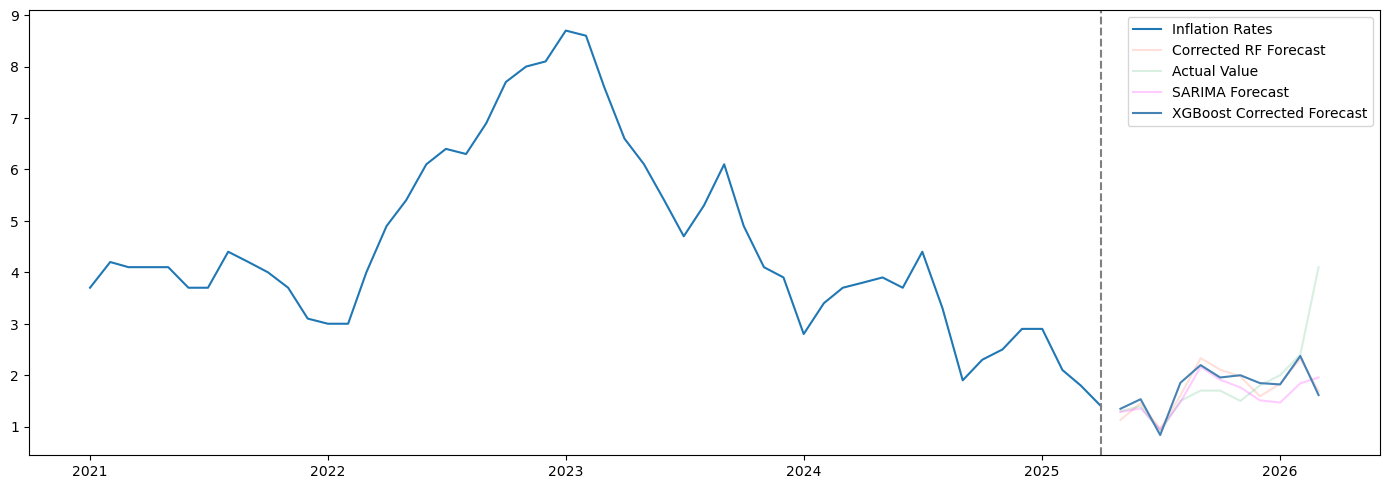

In [44]:
fig, ax = plt.subplots(figsize = (14,5))

ax.plot(inf_train.index, inf_train['inflation'], label = 'Inflation Rates')
ax.plot(index_range, corrected_rf_forecast, color = 'tomato', label = 'Corrected RF Forecast', alpha = 0.2)
ax.plot(index_range, inf_test['inflation'][0:11], color = 'mediumseagreen',alpha = 0.2, label = 'Actual Value')
ax.plot(index_range, forecast[0:11], color = 'magenta', label = 'SARIMA Forecast', alpha = 0.2)
ax.plot(index_range, corrected_xgb_forecast, color = 'steelblue', label = 'XGBoost Corrected Forecast')

ax.axvline(x = last_date, color = 'gray', linestyle = '--')
plt.legend()
plt.tight_layout()
plt.show()

In [45]:
ensembled_model = (corrected_rf_forecast + corrected_xgb_forecast)/2

print(f'ARIMA Forecast Error Matrix:')
err_metrics(inf_test['inflation'].dropna(), forecast.values[:11])
print('')
print(f'Corrected RF Forecast Error Matrix:')
err_metrics(inf_test['inflation'].dropna(), corrected_rf_forecast)
print('')
print(f'Corrected XGBoost Forecast Error Matrix:')
err_metrics(inf_test['inflation'].dropna(), corrected_xgb_forecast)
print('')
print(f'Corrected Ensemble Model Forecast Error Matrix:')
err_metrics(inf_test['inflation'].dropna(), ensembled_model)

ARIMA Forecast Error Matrix:
MSE: 0.5099099232079017
RMSE: 0.714079773700321
MAE: 0.41684898144454774

Corrected RF Forecast Error Matrix:
MSE: 0.6099825322822743
RMSE: 0.7810137849502237
MAE: 0.43367005173928436

Corrected XGBoost Forecast Error Matrix:
MSE: 0.6296294506938463
RMSE: 0.7934919348637681
MAE: 0.41673456919238827

Corrected Ensemble Model Forecast Error Matrix:
MSE: 0.6142326020535169
RMSE: 0.7837299292827326
MAE: 0.41175599123029544


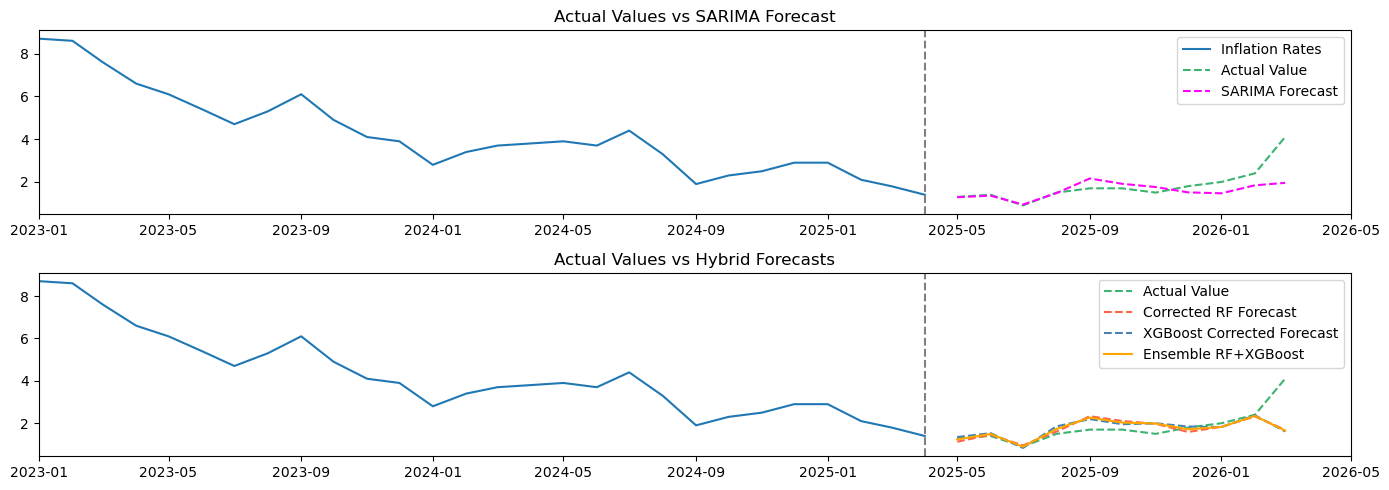

In [46]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize = (14,5))

ax1.plot(inf_train.index, inf_train['inflation'], label = 'Inflation Rates')
ax1.plot(index_range, inf_test['inflation'][0:11], color = 'mediumseagreen',linestyle = '--', label = 'Actual Value')
ax1.plot(index_range, forecast[0:11], color = 'magenta', label = 'SARIMA Forecast', linestyle = '--')
ax1.set_title('Actual Values vs SARIMA Forecast')
ax1.set_xlim(pd.Timestamp('2023-01-01'), pd.Timestamp('2026-05-01'))
ax1.legend()

ax2.plot(inf_train.index, inf_train['inflation'])
ax2.plot(index_range, inf_test['inflation'][0:11], color = 'mediumseagreen',linestyle = '--', label = 'Actual Value')
ax2.plot(index_range, corrected_rf_forecast, color = 'tomato', label = 'Corrected RF Forecast', linestyle = '--')
ax2.plot(index_range, corrected_xgb_forecast, color = 'steelblue', label = 'XGBoost Corrected Forecast',linestyle = '--')
ax2.plot(index_range, ensembled_model, color = 'orange', label = 'Ensemble RF+XGBoost')
ax2.set_xlim(pd.Timestamp('2023-01-01'), pd.Timestamp('2026-05-01'))
ax2.set_title('Actual Values vs Hybrid Forecasts')
ax2.legend()

ax1.axvline(x = last_date, color = 'gray', linestyle = '--')
ax2.axvline(x = last_date, color = 'gray', linestyle = '--')



plt.tight_layout()
plt.savefig('Model_evaluation_plot.png', dpi = 150, bbox_inches = 'tight')
plt.show()

#### Feature Engineering for Full Dataset

In [47]:
# Inflation Observation
inf_feature =df_final[['inflation']].set_index(df_final['month']).dropna()

# Observation features

future_dates = pd.date_range(start='2026-06-01', periods=3, freq='MS')
future_rows = pd.DataFrame(index=future_dates, columns=df_final.columns)
df_extended = pd.concat([df_final, future_rows])

final_exo_feature = df_extended.copy().drop('inflation', axis = 1)
final_exo_feature['usd_php'] = final_exo_feature['usd_php'].pct_change().shift(4)
final_exo_feature['oil_brent'] = final_exo_feature['oil_brent'].rolling(window = 3).mean().shift(2)
final_exo_feature['sentiment'] = final_exo_feature['sentiment'].rolling(window = 3).mean().shift(2)
final_exo_feature = final_exo_feature.set_index('month')


# Future exo features
print(f'Original df shape: {df_final.shape}')
print(f'Engineered shape: {final_exo_feature.shape}')
print(f'Inflation shape: {inf_feature.shape}')
print('')
print('final exo feature head')
print(final_exo_feature.head())
print('')
print('final_exo_feature tail')
print(final_exo_feature.tail())
print('')
print('inflation tail')
print(inf_feature.tail())
print('')
print('inflation head')
print(inf_feature.head())

Original df shape: (65, 5)
Engineered shape: (68, 3)
Inflation shape: (63, 1)

final exo feature head
            usd_php  oil_brent  sentiment
month                                    
2021-01-01      NaN        NaN        NaN
2021-02-01      NaN        NaN        NaN
2021-03-01      NaN        NaN        NaN
2021-04-01      NaN        NaN        NaN
2021-05-01      NaN  57.043332  -0.039234

final_exo_feature tail
             usd_php  oil_brent  sentiment
month                                     
2026-04-01 -0.001099  63.406667  -0.022942
2026-05-01  0.005325  68.263334  -0.001923
NaT        -0.014907  81.733335   0.012225
NaT         0.019331  95.690000   0.038509
NaT         0.014887        NaN        NaN

inflation tail
            inflation
month                
2025-11-01        1.5
2025-12-01        1.8
2026-01-01        2.0
2026-02-01        2.4
2026-03-01        4.1

inflation head
            inflation
month                
2021-01-01        3.7
2021-02-01        4.2
2021-

C:\Users\Marry Bless Magat\AppData\Local\Temp\ipykernel_34896\2512502294.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_extended = pd.concat([df_final, future_rows])
C:\Users\Marry Bless Magat\AppData\Local\Temp\ipykernel_34896\2512502294.py:11: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  final_exo_feature['usd_php'] = final_exo_feature['usd_php'].pct_change().shift(4)


#### Refitting Full Dataset to SARIMA model

In [48]:
final_arima_model = ARIMA(
    df_feature_engineered['inflation'],
    order = orders,
    seasonal_order= arima_model.seasonal_order,
    freq='MS'
)

final_arima_fit = final_arima_model.fit()

NameError: name 'df_feature_engineered' is not defined

#### Prediction

In [ ]:
forecast_length = 36
final_arima_forecast = final_arima_fit.get_forecast(steps = forecast_length)

forecast_values = final_arima_forecast.predicted_mean
forecast_ci = final_arima_forecast.conf_int()

forecast_values
forecast_ci

#### Plotting 36-month horizon forecast

In [ ]:
last_date = df_feature_engineered.index[-1]

In [ ]:
fig, ax = plt.subplots(figsize = (14,5))

ax.plot(df_feature_engineered['inflation'], color = 'steelblue', label  = 'Observation')
ax.plot(forecast_values.index, forecast_values.values, color = 'tomato', label = 'Final ARIMA Forecast')
ax.fill_between(
    forecast_values.index,
    forecast_ci.iloc[:,0],
    forecast_ci.iloc[:,1],
    alpha = 0.2, color = 'tomato', label = '95% CI')

ax.axvline(last_date, linestyle = '--', color = 'grey')
plt.legend()
plt.tight_layout()
plt.show()

#### Feature Engineering

In [ ]:
# Since we don't have observation for future features, we will assume that the feature values are the same as the last observation
# for the next 3 years

last_known = df_feature_engineered[['oil_brent', 'sentiment', 'usd_php']].iloc[-1]

future_features = pd.DataFrame(
    [last_known.values]*36,
    columns = last_known.index)


# Defining X and y
X_full = df_feature_engineered[['oil_brent', 'sentiment', 'usd_php']]
y_full = final_arima_fit.resid

#### Model Fitting

In [ ]:
rf_full = rf_model.fit(X_full, y_full)
xgb_full = xgb_model.fit(X_full, y_full)

#### Forecasting the Correction

In [ ]:
rf_full_forecast = rf_full.predict(future_features)
rf_full_forecast = rf_full_forecast + forecast_values.values
xgb_full_forecast = xgb_full.predict(future_features)
xgb_full_forecast = xgb_full_forecast+ forecast_values.values

ensemble_full = (rf_full_forecast + xgb_full_forecast)/2

In [ ]:
fig, ax = plt.subplots(figsize = (14,5))

ax.plot(df_feature_engineered['inflation'], color = 'steelblue', label  = 'Observation')
ax.plot(forecast_values.index, ensemble_full, color = 'mediumseagreen', label = 'Ensemble Model Correction')


ax.axvline(df_feature_engineered.index[-1], linestyle = '--', color = 'grey')
plt.legend()
plt.tight_layout()
plt.show()